# Probe weight breakdown

Coefficients of the joint linear probe, before and after CLIP alignment, for the
three targets it is read out for. One fit per panel row, no averaging over splits.

In [1]:
import sys, glob, re
import numpy as np, h5py, torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch
from astropy.table import Table
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from plotstyle import (ROOT, FIG_DIR, FUSION_DIR, EMBED_H5, DJA_FITS, C_IMAGE, C_SPECTRUM,
                       use_style, style_axes, fs, save)
sys.path.insert(0, str(FUSION_DIR))
from model.fusion import MultimodalFusion

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# CLIP-fusion checkpoint, highest retrieval R@10 of the run the paper used;
# set the run name to your own after training.
CKPT = max(glob.glob(str(FUSION_DIR / "outputs/fusion_dja_image_attn_spectrum_attn"
                          / "version_*/checkpoints/*R10=*.ckpt")),
           key=lambda p: float(re.search(r"R10=([0-9.]+)", p).group(1)))

FRAC_VALID_PIX, MIN_SN50 = 0.5, 0        # spectrum window coverage / median S/N
MAX_DZPHOT               = 0.15          # |z_phot - z_best|/(1+z): keep masses fitted at the right redshift
ZLO, ZHI                 = 1.0, 3.0      # table window
MAXZ_FIG                 = 7.0           # figure window
ALPHAS                   = 25           # points on LassoCV's data-adaptive path
SEED                     = 42

use_style()
print(f"device={DEVICE}\nckpt={CKPT.split('/')[-1]}")

device=cuda
ckpt=epoch=39-R10=0.158-val_loss=4.7346.ckpt


## 1. Sample

In [2]:
# === sample ===================================================================
# Everything below is read once; `sel_fig` is the redshift-binned figure sample and
# `zi` indexes the 1<z<=3 subset used for the table.
dja = Table.read(DJA_FITS)
with h5py.File(EMBED_H5, "r") as f:
    ids  = f["id"][:]
    surv = f["survey"][:].astype(str)
    sn   = f["sn50"][:]
    smask = f["spectrum_token_mask"][:].astype(bool)
    spec  = f["spectrum_patch_embed"][:]
    icls  = f["image_cls_embed"][:]
    istat = f["image_stats"][:].astype(np.float32)
    sstat = f["spectrum_stats"][:].astype(np.float32)
    spec_ok = np.isfinite(spec.reshape(len(ids), -1)).all(1)

with np.errstate(invalid="ignore", divide="ignore"):
    logm = np.log10(np.asarray(dja["phot_mass"])[ids].astype(np.float32))
z    = np.asarray(dja["z_best"])[ids].astype(np.float32)
zph  = np.asarray(dja["z_phot"])[ids].astype(np.float32)
f150 = np.asarray(dja["phot_f150w_tot_1"])[ids].astype(np.float64)

# phot_mass is an EAZY fit to the photometry, so it is only usable where the
# photometric redshift agrees with the spectroscopic one.
with np.errstate(invalid="ignore", divide="ignore"):
    dzp = np.abs((zph - z) / (1 + z))

# the cross-matched sample of Section 2 is built from the grade-filtered spectra,
# so the same cut is applied here to keep the sample chain consistent.
sys.path.insert(0, str(ROOT / "encoder_spectrum/LowResPT"))
from data.dataset import LowResDataset
_keep = np.asarray(LowResDataset(fits_path=str(DJA_FITS), grades=(1, 2, 3),
                                 frac_valid_pix=0.5).valid_indices)

sel_fig = (spec_ok & np.isfinite(logm) & np.isfinite(z) & (z > 0)
           & (smask.mean(1) > FRAC_VALID_PIX) & (sn > MIN_SN50)
           & np.isin(ids, _keep)
           & np.isfinite(dzp) & (dzp < MAX_DZPHOT) & (z <= MAXZ_FIG))
rows = np.where(sel_fig)[0]

# image patch tokens are the only large array: read just the selected rows
with h5py.File(EMBED_H5, "r") as f:
    d = f["image_patch_embed"]
    imgp = np.empty((len(rows), d.shape[1], d.shape[2]), np.float32)
    for s in range(0, len(rows), 512):
        imgp[s:s + 512] = d[rows[s:s + 512]]

spec, smask, icls = spec[rows], smask[rows], icls[rows]
istat, sstat      = istat[rows], sstat[rows]
y, zz, surv, ids  = logm[rows], z[rows], surv[rows], ids[rows]
lf                = np.log10(f150[rows])
print(f"figure sample (z<={MAXZ_FIG}): {len(rows)}   image tokens {imgp.shape}")

Converting flux from f_nu (uJy) to f_lambda (∝ f_nu / λ²) (use_jansky=True to disable this conversion)


grade in (1, 2, 3) filtering: 26486/42196 samples kept
valid_pix_frac > 0.5 filtering: 25025/42196 samples kept
LowResDataset: 25025 spectra, 56 pixels (1.004–1.991 µm)


figure sample (z<=7.0): 8269   image tokens (8269, 529, 512)


## 2. Frozen CLIP latents

In [3]:
# === frozen CLIP latents ======================================================
ck = torch.load(CKPT, map_location=DEVICE, weights_only=False)
hp = ck["hyper_parameters"]
fusion = MultimodalFusion(latent_dim=hp["latent_dim"], temperature=hp["temperature"])
for name, cfg in hp["modalities"].items():
    fusion.register_modality(name, input_dim={"image": imgp.shape[-1], "spectrum": spec.shape[-1]}[name],
                             hidden_dim=cfg.get("hidden_dim"), pool=cfg.get("pool"),
                             num_heads=cfg.get("num_heads", 4), stats_dim=cfg.get("stats_dim"))
fusion.load_state_dict({k[len("fusion."):]: v for k, v in ck["state_dict"].items()
                        if k.startswith("fusion.")}, strict=True)
fusion = fusion.to(DEVICE).eval()

@torch.no_grad()
def clip_latents(bs=256):
    raw = {"image": istat, "spectrum": sstat}
    ei, es = [], []
    for s in range(0, len(y), bs):
        sl = slice(s, s + bs)
        im = torch.from_numpy(imgp[sl]).to(DEVICE); sp = torch.from_numpy(spec[sl]).to(DEVICE)
        av = {n: torch.ones(im.shape[0], dtype=torch.bool, device=DEVICE) for n in ("image", "spectrum")}
        st = {m: torch.from_numpy(raw[m][sl]).to(DEVICE) for m in fusion.stats_encoders}
        e = fusion({"image": im, "spectrum": sp}, av,
                   {"spectrum": torch.from_numpy(smask[sl]).to(DEVICE)}, st or None)
        ei.append(e["image"].cpu().numpy()); es.append(e["spectrum"].cpu().numpy())
    return np.concatenate(ei), np.concatenate(es)

IMG_AL_ALL, SPC_AL_ALL = clip_latents()
print("aligned latents:", IMG_AL_ALL.shape, SPC_AL_ALL.shape)

aligned latents: (8269, 256) (8269, 256)


## 3. Representations and split

In [4]:
# === representations ==========================================================
# The unaligned readouts take the frozen encoder output with NO learned parameters, and
# are kept close in width to the 256-d aligned embedding so the comparison is not
# confounded by dimensionality: image = [CLS], spectrum = masked mean + masked max.
# Both append the raw (mean, std) flux statistics, which the aligned head also receives.
w      = smask[..., None].astype(np.float32)
smean  = (spec * w).sum(1) / np.clip(w.sum(1), 1, None)
smax   = np.nan_to_num(np.where(smask[..., None], spec, -np.inf).max(1), neginf=0.0)
ist, sst = np.arcsinh(istat), np.arcsinh(sstat)

IMG_UN_ALL = np.hstack([icls, ist])                    # [CLS] + stats
SPC_UN_ALL = np.hstack([smean, smax, sst])             # masked mean + max + stats
print(f"image un. {IMG_UN_ALL.shape[1]}d | spectrum un. {SPC_UN_ALL.shape[1]}d | "
      f"aligned {IMG_AL_ALL.shape[1]}d each")

zi = np.where((zz > ZLO) & (zz <= ZHI) & np.isfinite(lf))[0]     # table sample
PHOT     = lf[zi][:, None]
IMG_UN, SPC_UN = IMG_UN_ALL[zi], SPC_UN_ALL[zi]
IMG_AL, SPC_AL = IMG_AL_ALL[zi], SPC_AL_ALL[zi]
JNT_UN, JNT_AL = np.hstack([IMG_UN, SPC_UN]), np.hstack([IMG_AL, SPC_AL])
yz, zt, lft = y[zi], zz[zi], lf[zi]
tr, va = train_test_split(np.arange(len(zi)), test_size=0.5, random_state=SEED)
print(f"sample {ZLO}<z<={ZHI}: n={len(zi)}   train {len(tr)} / test {len(va)}")
# Targets and setups for the probe below: three quantities read out of the same
# joint vector, before and after alignment. `di` is the width of the image block.
TARGETS = [("redshift $z$", zt, "redshift"),
           ("log F150W", lft, "photometry"),
           (r"log $M_\star$", yz, "mass")]
SETUPS = [("un.", JNT_UN, IMG_UN.shape[1]), ("al.", JNT_AL, IMG_AL.shape[1])]


image un. 514d | spectrum un. 258d | aligned 256d each
sample 1.0<z<=3.0: n=3711   train 1855 / test 1856


## 4. Probe weights

An $L_1$ probe selects, so the number of surviving coefficients per block is a
sparse read of which modality each target is drawn from. Writes `probe_weights.png`.


target       setup       R2     NMAD  nonzero img  nonzero spc  sparsity  img |w|_1     alpha
--------------------------------------------------------------------------------------


redshift     un.      0.833   0.0605    109/514       91/258       74.1%      27.9%  4.47e-03


redshift     al.      0.798   0.0745     96/256       55/256       70.5%      20.3%  2.90e-04
photometry   un.      0.970   0.0862    166/514       42/258       73.1%      89.5%  2.13e-03


photometry   al.      0.964   0.0871     85/256       18/256       79.9%      98.1%  5.28e-04
mass         un.      0.903   0.2326    173/514       88/258       66.2%      58.3%  4.00e-03


mass         al.      0.897   0.2465     80/256       29/256       78.7%      78.5%  7.78e-04


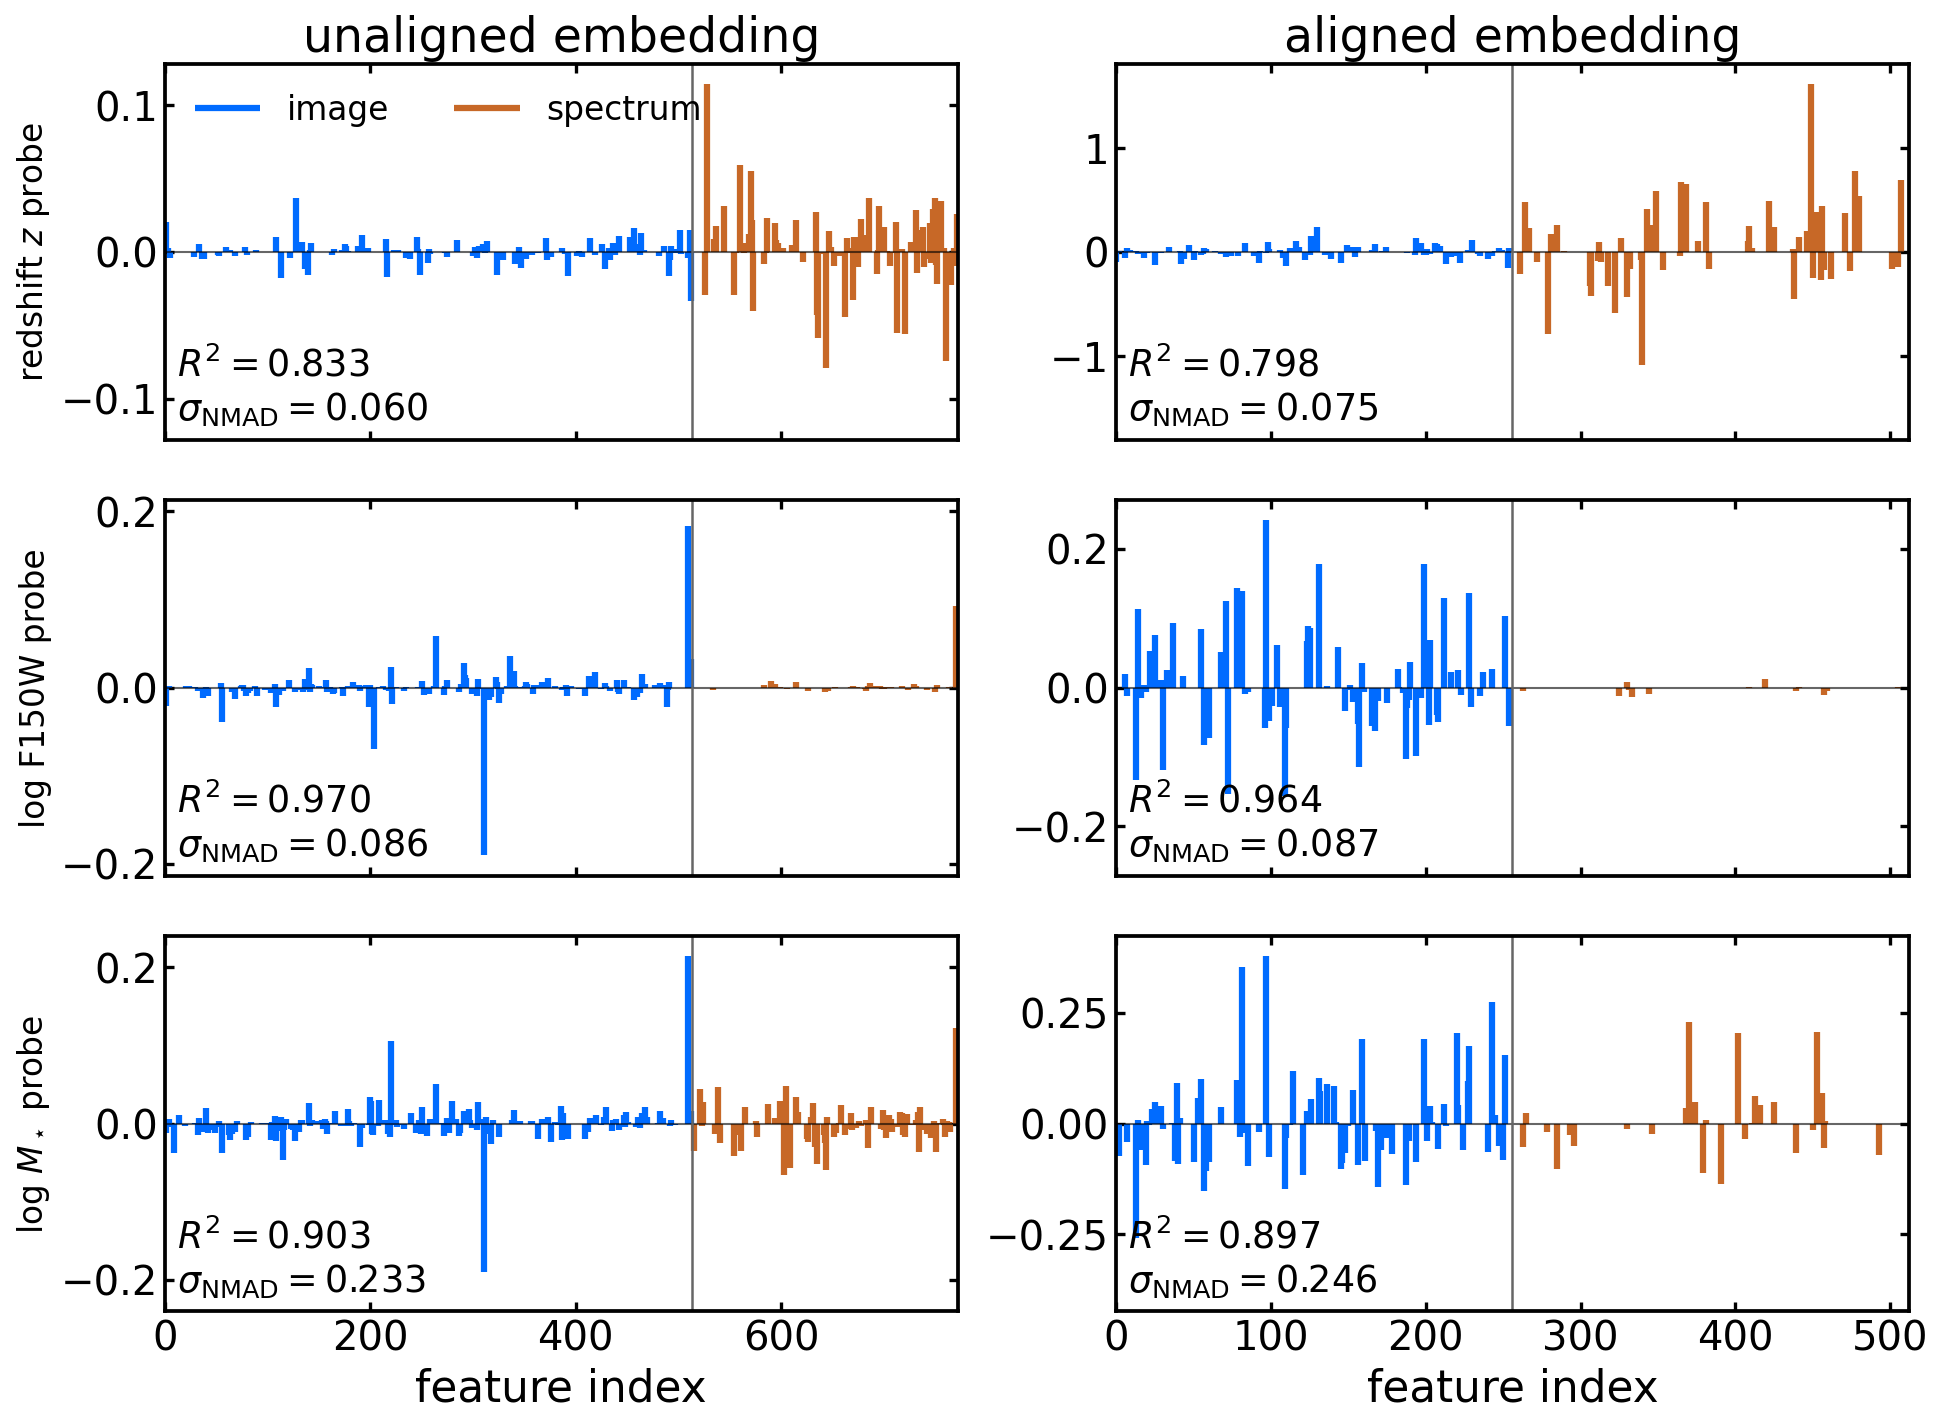

In [7]:
# === where the sparse probe puts its weight ===================================
# Each panel picks its own penalty by cross-validation on the training half, so
# every panel shows that setup's own sparse solution, and each panel is scaled
# to its own coefficients, with its tick labels on the left.
use_style(1.75)
SETUP_TITLE = {"un.": "unaligned embedding", "al.": "aligned embedding"}
LW = 3.0   # stem width


def probe_nmad(t_true, t_pred, fname):
    """sigma_NMAD of the residual; the redshift target uses the (1+z) convention."""
    e = t_pred - t_true
    if fname == "redshift":
        e = e / (1.0 + t_true)
    return 1.4826 * np.median(np.abs(e - np.median(e)))

fig, axes = plt.subplots(len(TARGETS), 2, figsize=(15, 3.6 * len(TARGETS)),
                         sharex="col", gridspec_kw=dict(wspace=0.20, hspace=0.16))
print(f"{'target':12s} {'setup':6s} {'R2':>7s} {'NMAD':>8s} {'nonzero img':>12s} {'nonzero spc':>12s} "
      f"{'sparsity':>9s} {'img |w|_1':>10s} {'alpha':>9s}")
print("-" * 86)
for r, (tname, t, fname) in enumerate(TARGETS):
    for k, (tag, X, di) in enumerate(SETUPS):
        sc = StandardScaler().fit(X[tr])
        Ztr, Zva = sc.transform(X[tr]), sc.transform(X[va])
        las = LassoCV(alphas=ALPHAS, cv=3, max_iter=200_000, tol=1e-3, n_jobs=-1,
                      selection="random", random_state=SEED).fit(Ztr, t[tr])
        w = las.coef_
        pred = las.predict(Zva)
        r2_l = r2_score(t[va], pred)
        nmad_l = probe_nmad(t[va], pred, fname)
        nz_i, nz_s = int((w[:di] != 0).sum()), int((w[di:] != 0).sum())
        l1i, l1s = np.abs(w[:di]).sum(), np.abs(w[di:]).sum()

        ax = axes[r, k]
        for sl, c, lab in ((slice(0, di), C_IMAGE, "image"),
                           (slice(di, None), C_SPECTRUM, "spectrum")):
            idx = np.flatnonzero(w[sl]) + (0 if sl.start == 0 else di)
            ax.vlines(idx, 0, w[sl][w[sl] != 0], color=c, lw=LW, label=lab)
        ax.axhline(0, color="k", lw=1.0, alpha=0.6)
        ax.axvline(di - 0.5, color="0.4", lw=1.2)
        ax.set_xlim(0, w.size)
        lim = 1.12 * np.abs(w).max()
        ax.set_ylim(-lim, lim)
        if r == 0:
            ax.set_title(SETUP_TITLE[tag], fontsize=fs(13))
        if r == len(TARGETS) - 1:
            ax.set_xlabel("feature index", fontsize=fs(12))
        if k == 0:
            ax.set_ylabel(f"{tname} probe", fontsize=fs(9))
        if r == 0 and k == 0:
            ax.legend(fontsize=fs(9), frameon=False, ncol=2, loc="upper left")
        ax.text(0.015, 0.03,
                f"$R^2={r2_l:.3f}$\n$\\sigma_{{\\rm NMAD}}={nmad_l:.3f}$",
                transform=ax.transAxes, va="bottom", ha="left", fontsize=fs(10))
        style_axes(ax, labelsize=fs(11))

        print(f"{fname:12s} {tag:6s} {r2_l:7.3f} {nmad_l:8.4f} "
              f"{nz_i:6d}/{di:<5d} {nz_s:6d}/{w.size-di:<5d} "
              f"{100*(w == 0).mean():8.1f}% {100*l1i/(l1i+l1s):9.1f}% {las.alpha_:9.2e}")

fig.patch.set_alpha(0.0)
save(fig, "probe_weights")
plt.show()


## Split-to-split scatter of the $L_1$ probes


In [8]:
# === split-to-split scatter of the six panels =================================
# Each panel of the figure is one 50/50 split. To quote an uncertainty we hold
# that panel's cross-validated penalty fixed and repeat the fit over N_SCATTER
# random splits. The redshift residual uses the (1+z) convention, the other two
# targets are in dex. The mass rows also report the outlier fraction, which is
# the number quoted for the L1 probe in the appendix.
from sklearn.linear_model import Lasso

N_SCATTER = 40


def _resid(t_true, t_pred, fname):
    e = t_pred - t_true
    return e / (1.0 + t_true) if fname == "redshift" else e


print(f"{'target':12s} {'setup':6s} {'R2':>16s} {'sigma_NMAD':>18s} {'f>0.5':>9s} {'alpha':>10s}")
print("-" * 78)
_worst_r2 = _worst_nm = 0.0
for tname, t, fname in TARGETS:
    for tag, X, di in SETUPS:
        sc = StandardScaler().fit(X[tr])
        a = LassoCV(alphas=ALPHAS, cv=3, max_iter=200_000, tol=1e-3, n_jobs=-1,
                    selection="random", random_state=SEED).fit(sc.transform(X[tr]), t[tr]).alpha_
        r2s, nms, fos = [], [], []
        for s in range(N_SCATTER):
            i_tr, i_va = train_test_split(np.arange(len(t)), test_size=0.5, random_state=s)
            sc = StandardScaler().fit(X[i_tr])
            m = Lasso(alpha=a, max_iter=200_000, tol=1e-3, selection="random",
                      random_state=SEED).fit(sc.transform(X[i_tr]), t[i_tr])
            p = m.predict(sc.transform(X[i_va]))
            e = _resid(t[i_va], p, fname)
            r2s.append(r2_score(t[i_va], p))
            nms.append(1.4826 * np.median(np.abs(e - np.median(e))))
            fos.append(100 * np.mean(np.abs(p - t[i_va]) > 0.5))
        r2s, nms, fos = np.array(r2s), np.array(nms), np.array(fos)
        _worst_r2 = max(_worst_r2, r2s.std()); _worst_nm = max(_worst_nm, nms.std())
        print(f"{fname:12s} {tag:6s} {r2s.mean():7.3f}+/-{r2s.std():5.3f} "
              f"{nms.mean():8.4f}+/-{nms.std():6.4f} "
              f"{fos.mean():6.1f}+/-{fos.std():3.1f}% {a:10.2e}")

print(f"\nfigure caption: split-to-split standard deviations are at most "
      f"{_worst_r2:.3f} in R2 and {_worst_nm:.3f} in sigma_NMAD")


target       setup                R2         sigma_NMAD     f>0.5      alpha
------------------------------------------------------------------------------


redshift     un.      0.824+/-0.005   0.0597+/-0.0019    4.3+/-0.4%   4.47e-03


redshift     al.      0.776+/-0.007   0.0741+/-0.0016    5.7+/-0.4%   2.90e-04


photometry   un.      0.968+/-0.002   0.0810+/-0.0021    0.5+/-0.1%   2.13e-03


photometry   al.      0.964+/-0.003   0.0865+/-0.0024    0.5+/-0.1%   5.28e-04


mass         un.      0.900+/-0.004   0.2419+/-0.0058    8.2+/-0.6%   4.00e-03


mass         al.      0.896+/-0.003   0.2492+/-0.0048    9.1+/-0.5%   7.78e-04

figure caption: split-to-split standard deviations are at most 0.007 in R2 and 0.006 in sigma_NMAD
